# Neural Networks — Practice 1
## Build Your First Neural Network
### Master in Economics and Data Science · Neural Networks Intro

---

**Objectives of this session:**
- Set up a complete ML environment in Google Colab
- Load and explore a real financial dataset
- Build, train and evaluate a neural network from scratch
- Understand what the results mean

**Dataset:** [Default of Credit Card Clients](https://archive.ics.uci.edu/ml/datasets/default+of+credit+card+clients) — 30,000 bank customers, Taiwan 2005. Task: predict whether a customer will default next month.

**Time:** ~2 hours

You can run each cell with `Shift + Enter`. Read the comments carefully before filling in the blanks.


## 0. Setup — Install & Import Libraries

In [ ]:
# All packages are pre-installed in Google Colab — just run this cell!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility (learning purposes)
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", bool(tf.config.list_physical_devices('GPU')))


TensorFlow version: 2.19.0
GPU available: False


---
## 1. Load & Explore the Data

Before building any model, we need to **understand our data**.
Always ask:
- How many samples and features?
- Is the target balanced?
- Are there missing values?
- What do the distributions look like?


In [ ]:
# Load the dataset directly from UCI repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
df = pd.read_excel(url, header=1)
df = df.rename(columns={'default payment next month': 'default'})

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 1.1 Explore the target variable

Class distribution:
default
0    23364
1     6636
Name: count, dtype: int64

Default rate: 22.1 %


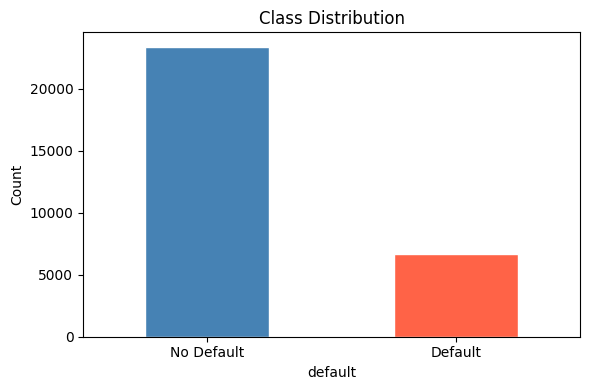

In [ ]:
# Count how many defaults vs non-defaults
print("Class distribution:")
print(df['default'].value_counts())
print()
print("Default rate:", round(df['default'].mean() * 100, 1), "%")

# Plot it
plt.figure(figsize=(6, 4))
df['default'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.xticks([0, 1], ['No Default', 'Default'], rotation=0)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


### Question 1.1
> **Look at the class distribution. What percentage of customers default?**
> **Why might this be a problem if we just use accuracy as our metric?**


**Answer:**

22.1% of the people default.
Using accuracy as our metric might cause problems because accuracy is better for telling us the results when there is a balanced dataset with a similar number of defaults and not-defaults. as the proportion of defaults and not-defaults is skewed towards not-defaults, accuracy cannot tell us the number of defaults which is what we are concerned about. It is good for telling us not-defaults (high accuracy).


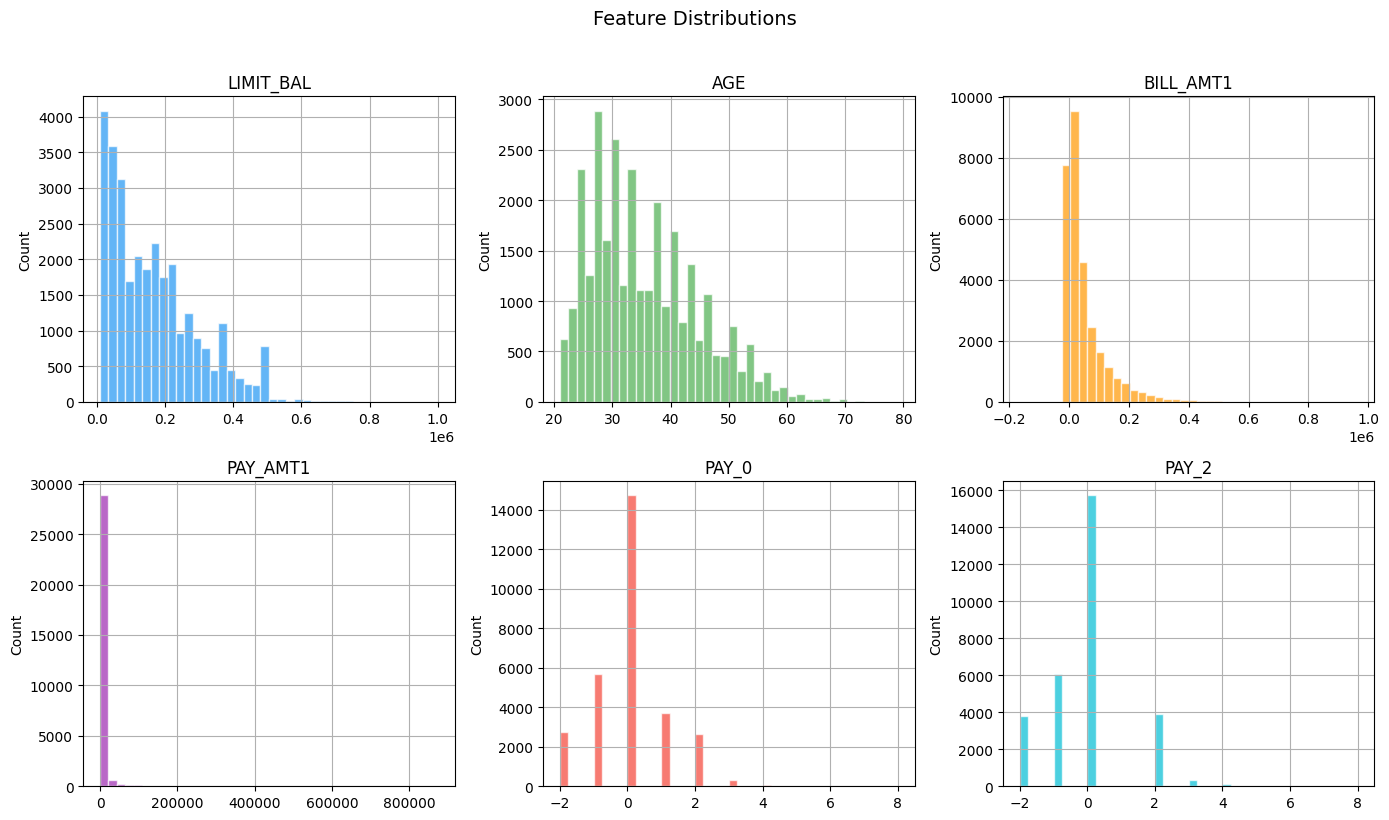

In [ ]:
# Explore distributions of a few key features
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
features = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1', 'PAY_0', 'PAY_2']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for ax, feat, col in zip(axes.flatten(), features, colors):
    df[feat].hist(bins=40, ax=ax, color=col, alpha=0.7, edgecolor='white')
    ax.set_title(feat)
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 1.2 Check for missing values

In [ ]:
# Check missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values!")
print()
print("Total features:", df.shape[1] - 2, "(excluding ID and target)")


Missing values per column:
No missing values!

Total features: 23 (excluding ID and target)


---
## 2. Preprocess the Data

Neural networks require:
1. **Numeric inputs** (already the case here)
2. **Standardized scale** — very important! Neurons are sensitive to input magnitude
3. **Proper train/val/test split** — never evaluate on training data


### 2.1 Separate features and target

In [ ]:
# Separate features (X) and target (y)
# Drop 'ID' (not useful) and 'default' (this is what we predict)
X = df.drop(['ID', 'default'], axis=1).values
y = df['default'].values

print("X shape:", X.shape)  # (30000, 23)
print("y shape:", y.shape)  # (30000,)
print("Number of features:", X.shape[1])


X shape: (30000, 23)
y shape: (30000,)
Number of features: 23


### 2.2 Split into train / validation / test

#### Your turn!
Split the data into:
- **Training set** (70%)
- **Validation set** (15%) — used to monitor training and tune hyperparameters
- **Test set** (15%) — only used for final evaluation, never touched during training

Use `train_test_split` from sklearn. Set `random_state=42`.


In [ ]:
# STEP 1: Split off 30% as 'temp' (will become val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,       # ← What fraction goes to temp?
    random_state=42,
    stratify=y           # Keep class proportions in each split
)

# STEP 2: Split 'temp' in half: 50% val, 50% test (= 15% each overall)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=.5,       # ← What fraction?
    random_state=42,
    stratify=y_temp
)

print(f"Training:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")


Training:   21,000 samples (70%)
Validation: 4,500 samples (15%)
Test:       4,500 samples (15%)


### 2.3 Standardize the features

> **Critical rule:** Fit the scaler **only on training data**, then apply to validation and test.
> If you fit on all data, information from the future (test set) leaks into training → your results will be optimistic and wrong.


In [ ]:
# Create the scaler
scaler = StandardScaler()

# Fit on train, transform train
X_train = scaler.fit_transform(X_train)

# Only transform (don't fit!) val and test
X_val  = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Verify: training data should have mean≈0 and std≈1
print("After scaling — Training set:")
print(f"  Mean: {X_train.mean():.4f}  (should be ≈ 0)")
print(f"  Std:  {X_train.std():.4f}   (should be ≈ 1)")


After scaling — Training set:
  Mean: 0.0000  (should be ≈ 0)
  Std:  1.0000   (should be ≈ 1)


---
## 3. Build the Neural Network

We'll build a **feedforward neural network** (also called MLP — Multi-Layer Perceptron).

**Architecture we'll start with:**
```
Input (23 features)
    ↓
Dense layer (64 neurons, ReLU)
    ↓
Dense layer (32 neurons, ReLU)
    ↓
Output (1 neuron, Sigmoid) → probability of default
```


#### Your turn! Build the model

In [ ]:
# Build the model using Keras Sequential API
model = keras.Sequential([

    # First hidden layer: 64 neurons, ReLU activation
    # input_shape tells Keras how many features we have
    layers.Dense(64, activation='relu', input_shape=(23,)),

    # Second hidden layer: 32 neurons
    layers.Dense(32, activation='relu'),

    # Output layer: 1 neuron for binary classification
    # What activation function do we use for binary output?
    layers.Dense(1, activation='sigmoid')
])

# Compile: choose optimizer, loss function, and metrics to track
model.compile(
    optimizer='adam',                  # Adam optimizer (default lr=0.001)
    loss='binary_crossentropy',        # Loss for binary classification
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# Print a summary of the architecture
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,649 (14.25 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

#### Question 3.1
> **How many trainable parameters does the model have?**
> **Where do these parameters come from? (Hint: think about the connection between layers)**

**Answer:**
* There are 3649 trainable parameters.
* From the first layer we get: we have 64 nodes with which we combine the 23 features and the 1 bias node. This gives us 64x24 = 1536.
* From the second layer we have 32 nodes in which we combine the 65 inputs (64 from before and 1 bias) and we get: 32x65=2080
* And then the last one is the output layer we combine the 33 outputs from the previous layers just one time and the parameters are the coefficients.

---
## 4. Train the Model

Now we run the **training loop**:
1. Forward pass → prediction
2. Compute loss
3. Backward pass (backpropagation)
4. Update weights

Keras handles all of this with `.fit()`.


In [ ]:
# Train for 50 epochs, batch size 256
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, y_val),
    verbose=1   # Show progress
)


Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7784 - auc: 0.6162 - loss: 0.5346 - val_accuracy: 0.8067 - val_auc: 0.6979 - val_loss: 0.4698
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8122 - auc: 0.7234 - loss: 0.4627 - val_accuracy: 0.8089 - val_auc: 0.7350 - val_loss: 0.4512
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8158 - auc: 0.7492 - loss: 0.4481 - val_accuracy: 0.8149 - val_auc: 0.7501 - val_loss: 0.4450
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8177 - auc: 0.7610 - loss: 0.4414 - val_accuracy: 0.8169 - val_auc: 0.7570 - val_loss: 0.4418
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8195 - auc: 0.7685 - loss: 0.4373 - val_accuracy: 0.8173 - val_auc: 0.7610 - val_loss: 0.4400
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8204 - auc: 0.7738 - loss: 0.4344 - val_accuracy: 0.8182 - val_auc: 0.7630 - val_loss: 0.4389
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - 

### 4.1 Plot the training curves

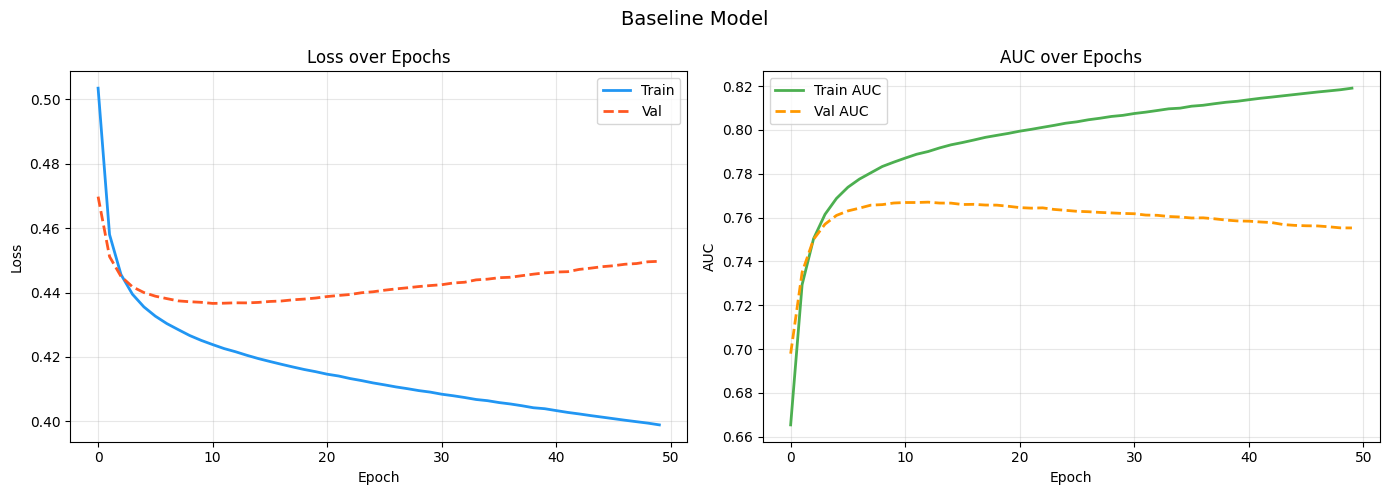

In [ ]:
def plot_history(history, title='Training Curves'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    axes[0].plot(history.history['loss'],     label='Train', linewidth=2, color='#2196F3')
    axes[0].plot(history.history['val_loss'], label='Val',   linewidth=2, color='#FF5722', linestyle='--')
    axes[0].set_title('Loss over Epochs')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # AUC curves
    axes[1].plot(history.history['auc'],     label='Train AUC', linewidth=2, color='#4CAF50')
    axes[1].plot(history.history['val_auc'], label='Val AUC',   linewidth=2, color='#FF9800', linestyle='--')
    axes[1].set_title('AUC over Epochs')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('AUC')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_history(history, 'Baseline Model')


### Question 4.1
> **Look at the training curves.**
> - Do train and validation loss move together, or do they diverge?
> - What does this tell you about overfitting?
> - At what epoch did the model stop improving significantly?

**Answer:**

* They diverge
* The model starts to overfit after the early epochs because training performance improves while validation performance worsens
* Around epoch 8–10 (it was minimum here and then the AUC started to rise)


---
## 5. Evaluate the Model

We **never** evaluate on training data. We use the **test set** — data the model has never seen.


#### Your turn! Generate predictions

In [ ]:
# Get predicted probabilities for the test set
y_pred_prob = model.predict(X_test).flatten()

# Convert probabilities to binary predictions using threshold = 0.5
# If probability >= 0.5 → predict default (1), otherwise no default (0)
y_pred = (y_pred_prob >= .5).astype(int)

print(f"Predicted defaults: {y_pred.sum()} / {len(y_pred)}")
print(f"True defaults:      {y_test.sum()} / {len(y_test)}")


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted defaults: 530 / 4500
True defaults:      996 / 4500


In [ ]:
# AUC-ROC score
auc = roc_auc_score(y_test, y_pred_prob)
print(f"🎯 AUC-ROC: {auc:.4f}")
print()

# Full classification report
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))


🎯 AUC-ROC: 0.7596

              precision    recall  f1-score   support

  No Default       0.83      0.94      0.89      3504
     Default       0.63      0.34      0.44       996

    accuracy                           0.81      4500
   macro avg       0.73      0.64      0.66      4500
weighted avg       0.79      0.81      0.79      4500



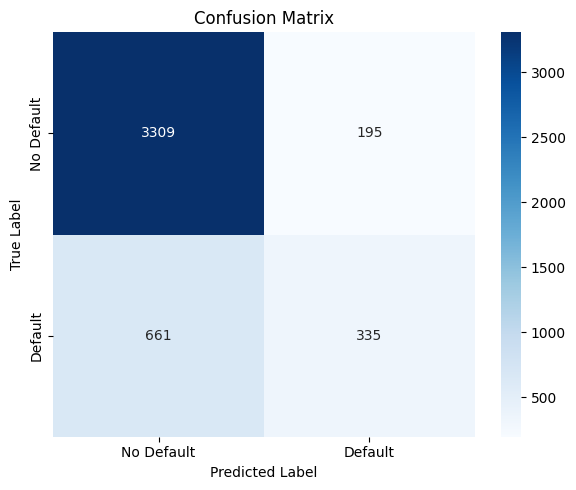

True Negatives  (correctly predicted No Default): 3,309
False Positives (false alarms):                   195
False Negatives (missed defaults):                661
True Positives  (correctly predicted Default):    335


In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Interpret
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted No Default): {tn:,}")
print(f"False Positives (false alarms):                   {fp:,}")
print(f"False Negatives (missed defaults):                {fn:,}")
print(f"True Positives  (correctly predicted Default):    {tp:,}")


### Question 5.1
> **Is AUC-ROC a better metric than accuracy here? Why?**
> **What would a 'perfect' AUC score be? What does AUC = 0.5 mean?**

**Answer:**
* AUC-ROC is a better metric than accuracy here because the dataset we have used is imbalanced. There are more No Default cases than Default cases, so a model could achieve high accuracy simply by predicting the majority class.
* AUC-ROC evaluates how well the model separates the two classes across different thresholds which makes it more informative for imbalanced dataset problems.
* A perfect AUC score is 1.0, which means the model perfectly distinguishes between the positive and negative classes.
* An AUC of 0.5 means the model performs no better than random guessing.

---
## 6. Experiments — Your Turn!

Now it's time to experiment. **Change ONE thing at a time** and compare results.
Record your findings in the table at the bottom.


### Experiment A: Change the number of neurons

Try making the first layer wider (128 neurons) or narrower (16 neurons).
What happens to the AUC?


In [ ]:
# Build a new model with DIFFERENT width
model_a = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(23,)),  # ← Change this!
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_a.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy', keras.metrics.AUC(name='auc')])

history_a = model_a.fit(X_train, y_train, epochs=50, batch_size=256,
                        validation_data=(X_val, y_val), verbose=0)

auc_a = roc_auc_score(y_test, model_a.predict(X_test).flatten())
print(f"Experiment A — AUC: {auc_a:.4f}")
print(f"Baseline      — AUC: {auc:.4f}")
print(f"Difference:          {auc_a - auc:+.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Experiment A — AUC: 0.7597
Baseline      — AUC: 0.7596
Difference:          +0.0001


### Experiment B: Add a third hidden layer

Add an extra hidden layer between the two existing ones. Does depth help?


In [ ]:
# Build a model with 3 hidden layers
model_b = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(23,)),
    layers.Dense(48, activation='relu'),  # ← Add layer here
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model_b.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy', keras.metrics.AUC(name='auc')])

history_b = model_b.fit(X_train, y_train, epochs=50, batch_size=256,
                        validation_data=(X_val, y_val), verbose=0)

auc_b = roc_auc_score(y_test, model_b.predict(X_test).flatten())
print(f"Experiment B (3 layers) — AUC: {auc_b:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Experiment B (3 layers) — AUC: 0.7534


### Experiment C: Replace ReLU with Sigmoid everywhere

What happens if you use sigmoid activations in hidden layers instead of ReLU?


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Experiment C (sigmoid hidden) — AUC: 0.7707


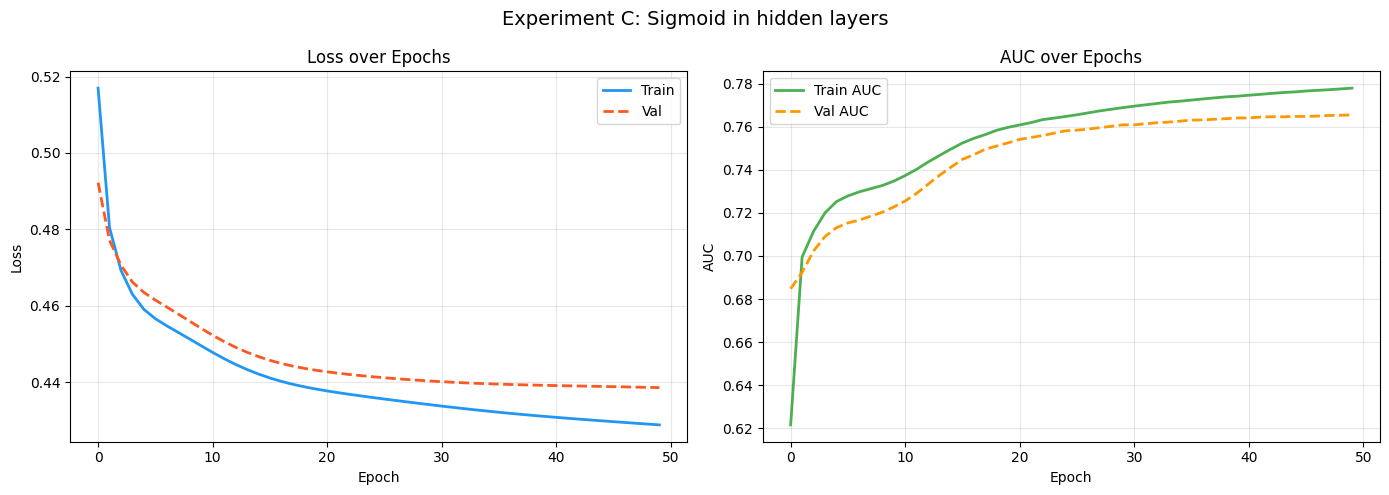

In [ ]:
# Build a model with sigmoid activations in hidden layers
model_c = keras.Sequential([
    layers.Dense(64, activation='sigmoid', input_shape=(23,)),  # ← Change activation
    layers.Dense(32, activation='sigmoid'),                       # ← And here
    layers.Dense(1, activation='sigmoid')
])

model_c.compile(optimizer='adam', loss='binary_crossentropy',
                metrics=['accuracy', keras.metrics.AUC(name='auc')])

history_c = model_c.fit(X_train, y_train, epochs=50, batch_size=256,
                        validation_data=(X_val, y_val), verbose=0)

auc_c = roc_auc_score(y_test, model_c.predict(X_test).flatten())
print(f"Experiment C (sigmoid hidden) — AUC: {auc_c:.4f}")
plot_history(history_c, "Experiment C: Sigmoid in hidden layers")


### Question 6.1 — Reflect on your experiments
> **Fill in the table with your results:**

| Experiment | Change | Val AUC | Observation |
|---|---|---|---|
| Baseline | 64→32 neurons, ReLU |0.7596| There is some overfitting after the early epochs|
| A | Different width |0.7597| here, changing the width did not have a significant effect, this is similar to the baseline|
| B | 3 hidden layers |0.7534| slightly worse performance? optimization may have been made more difficult|
| C | Sigmoid in hidden layers |0.7707| This model overfits less than the baseline|

> **Which experiment surprised you most? Why do you think it performed that way?**

**Answer:**
I think Experiment 3 with the sigmoid in the hidden layers was surprising because ReLu is usually expected to perform better than Sigmoid. Here, Sigmoid was much better than ReLu and we can see that there was less overfitting here.


---
## 7. Summary

Congratulations! You've:
- ✅ Loaded and explored a real financial dataset
- ✅ Preprocessed data correctly (split → scale, no leakage)
- ✅ Built a neural network from scratch in ~10 lines of Keras
- ✅ Trained it and interpreted the learning curves
- ✅ Evaluated with AUC-ROC, precision, recall, and a confusion matrix
- ✅ Experimented with architecture changes

**Next session:** We'll learn WHY this worked (backpropagation), and how to make the model even better with regularization techniques.

### 🔗 Resources to explore further:
- 3Blue1Brown: https://youtube.com/watch?v=aircAruvnKk
- Nielsen's book: http://neuralnetworksanddeeplearning.com (Chapters 1–2)
- TensorFlow playground (visual): https://playground.tensorflow.org
